# **Automatic White Balance with cv2.xphoto**

## **Objectives:**
1. Correct a known, reproducible color cast with `cv2.xphoto`'s `GrayworldWB` and `SimpleWB` — no external model
2. Score both correctors against the real original with notebook 20's MSE/SSIM (plus PSNR, notebook 35's addition) — a ground-truth check, not just "it looks better"
3. Find a real case where one algorithm's core assumption fails outright, and a genuine surprise about what the numbers actually reward

> **Assets.** No new files — reuses notebook 3's exact `assets/images/castara.jpeg`. `cv2.xphoto` ships in the `opencv-contrib` wheel this repo already pins.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Two different assumptions about what "correct" means**

- **`GrayworldWB`** assumes that, averaged over a whole photo, the *true* scene color should land close to neutral gray — enough different-colored objects in a typical scene cancel out on average. It scales each color channel to pull the image's overall average toward gray. That assumption is the whole method — and it fails hard the moment a photo is legitimately, overwhelmingly one color.
- **`SimpleWB`** assumes nothing about the scene's average color at all. It stretches each channel's darkest and brightest few percent out to true black and white (a per-channel contrast stretch), on the idea that a real white/black point exists *somewhere* in the frame, regardless of what the rest of the scene looks like.

## **A reproducible test: apply a known cast, try to undo it**

Same discipline as notebook 35's downscale-then-recover test — start from a real photo, apply an exact, known distortion, and keep the untouched original around as honest ground truth. `castara.jpeg` (notebook 3) turns out to be a genuinely interesting case: it's a fruit still life, dominated by warm orange and yellow citrus — about as far from "the scene averages to gray" as a photo gets.

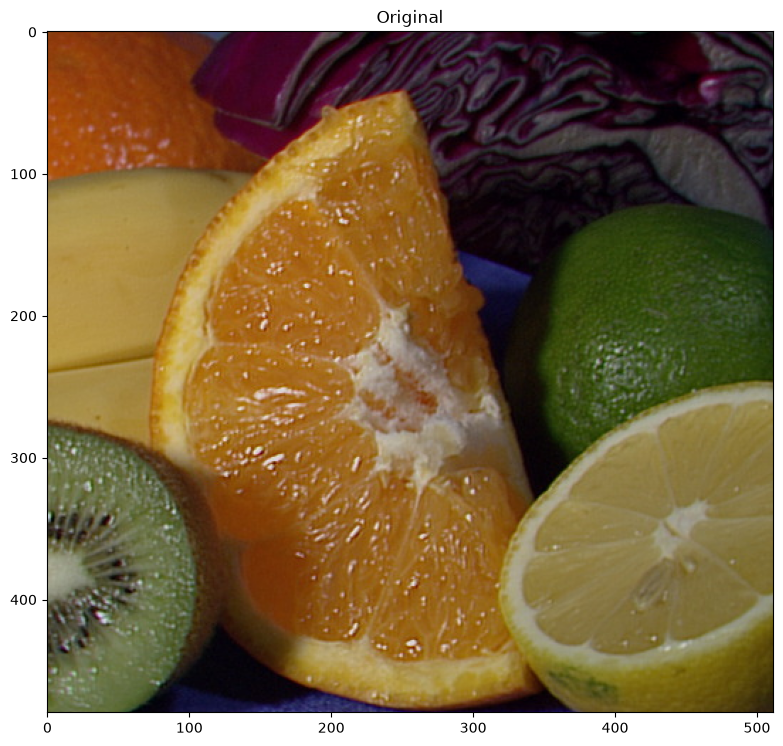

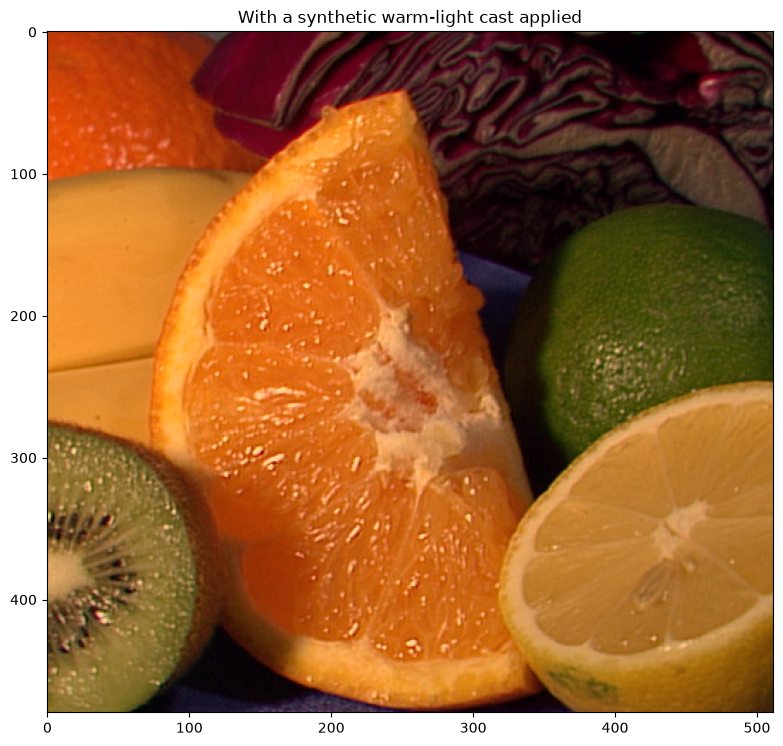

In [2]:
original = cv2.imread('assets/images/castara.jpeg').astype(np.float32)

# A plausible incandescent-lighting cast: warmer (more red), cooler light lost (less blue)
cast = original.copy()
cast[:, :, 2] *= 1.35   # R channel (BGR order)
cast[:, :, 0] *= 0.70   # B channel
cast = np.clip(cast, 0, 255).astype(np.uint8)
original = original.astype(np.uint8)

imshow('Original', original)
imshow('With a synthetic warm-light cast applied', cast)

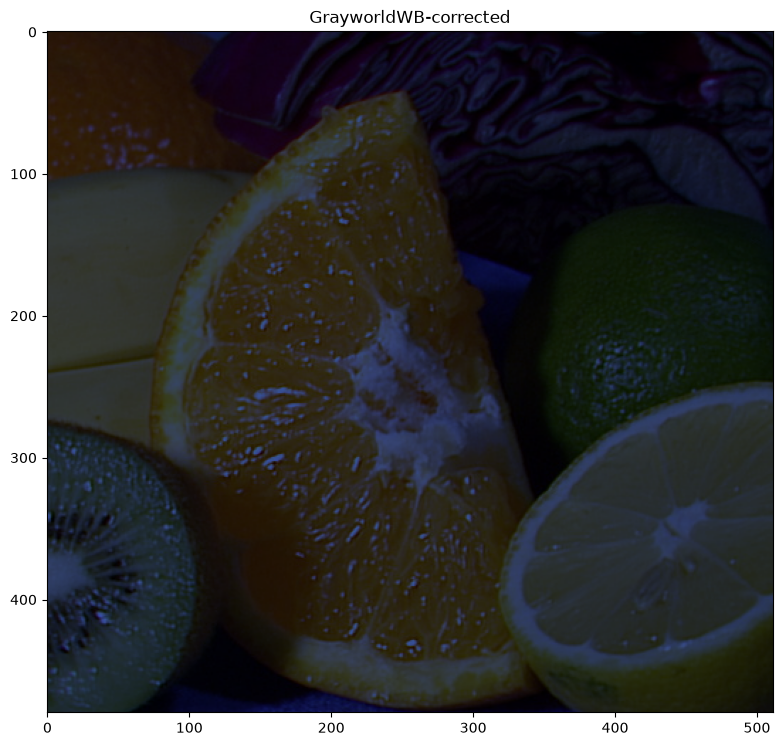

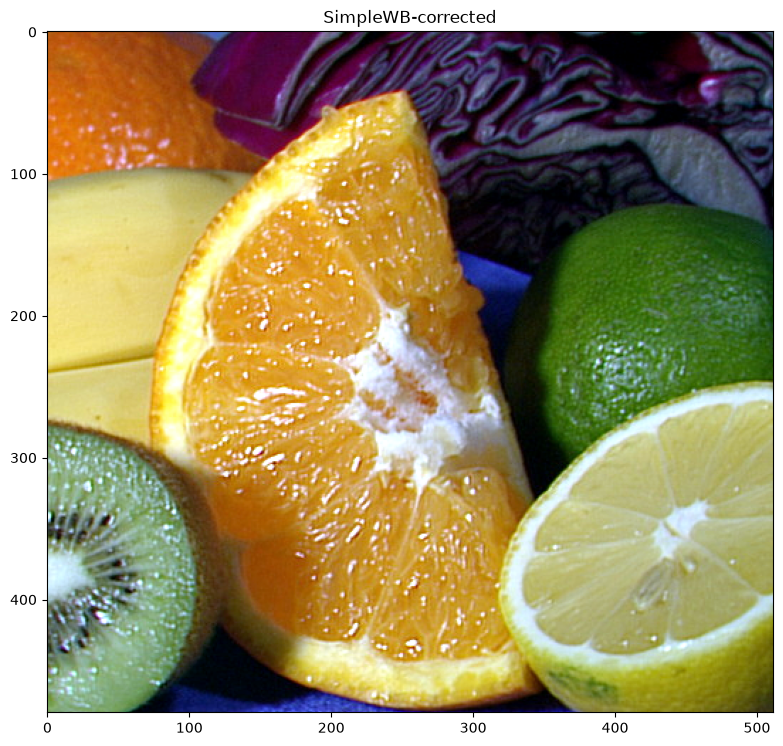

In [3]:
gw = cv2.xphoto.createGrayworldWB()
gw.setSaturationThreshold(0.99)
corrected_gw = gw.balanceWhite(cast)

sw = cv2.xphoto.createSimpleWB()
corrected_sw = sw.balanceWhite(cast)

imshow('GrayworldWB-corrected', corrected_gw)
imshow('SimpleWB-corrected', corrected_sw)

`GrayworldWB`'s result is visibly, badly wrong — dark and blue-shifted, nothing like the true original. It did exactly what it always does: pull the image average toward gray. The problem is that this photo's *true* average genuinely isn't gray — it's a bowl of citrus fruit — so "fixing" it toward gray actively makes it worse. `SimpleWB`, which never assumed anything about the average color, looks like a clean, convincing correction by eye.

## **Scoring against the real original**

Reusing notebook 20's MSE/SSIM and notebook 35's PSNR, all against the untouched `original` — plus the raw per-channel mean difference, which is a direct measure of how much color cast is actually left.

In [4]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

def score(name, image):
    g1 = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mse = np.mean((original.astype(np.float32) - image.astype(np.float32)) ** 2)
    print(f'{name:20s}  MSE={mse:8.1f}   SSIM={structural_similarity(g1, g2):.4f}   '
          f'PSNR={peak_signal_noise_ratio(original, image):5.2f}dB')

score('Cast (uncorrected)', cast)
score('GrayworldWB', corrected_gw)
score('SimpleWB', corrected_sw)

Cast (uncorrected)    MSE=   697.7   SSIM=0.9910   PSNR=19.69dB
GrayworldWB           MSE=  3990.0   SSIM=0.5390   PSNR=12.12dB
SimpleWB              MSE=  1981.6   SSIM=0.8911   PSNR=15.16dB


## **The surprise — and why it happens**

By every one of these numbers, the **uncorrected cast scores best**. `GrayworldWB` scores worst, matching what your eyes already told you. But `SimpleWB` — the one that looks like a genuinely good fix — *also* scores worse than doing nothing at all.

This is the same lesson notebook 35 found with super-resolution, from a different direction. The synthetic cast applied above is an exact, uniform multiplicative scale on each channel — mathematically, about as easy a distortion to be numerically "close" to the original as exists, since every pixel's error is small and perfectly consistent. Real correction algorithms don't know the exact `1.35`/`0.70` factors used — they *estimate* a correction from the image content using their own heuristics, and that estimate carries its own error on top of removing the original one. A genuinely useful correction can still land numerically *further* from the original than an obviously-wrong photo did, simply because "wrong in one precise, uniform way" and "corrected with a different, independent kind of error" are not the same distance in pixel space.

None of this means `SimpleWB` failed — visually, it's the clear winner, and that's what actually matters for a real photo with an unknown cast (where "just leave it uncorrected" isn't a ground truth you get to cheat with, unlike this notebook's synthetic test). The honest takeaway is narrower and more useful: **`GrayworldWB` is only as good as its gray-average assumption, which a color-dominated photo like this one genuinely violates — and a pixel-difference metric can reward "technically closer to a known distortion" over "visually correct" in exactly the way notebook 35 already warned about.**

### Worth a second look

- Run `GrayworldWB` on a scene where its assumption actually holds — `assets/images/tobago.jpg` or `oxfordlibrary.jpeg` have a much more varied color palette than a bowl of citrus fruit — and check whether it stops losing to `SimpleWB`.
- `cv2.xphoto.createLearningBasedWB()` exists too (a small trained model, not used here to keep this notebook dependency-free) — worth trying if a learned corrector handles this exact fruit-bowl failure case better than either heuristic.
- `cv2.ccm`'s `ColorCorrectionModel` takes a completely different, more rigorous approach — fit a correction from a real photographed Macbeth color chart with known reference values, rather than guessing from scene statistics at all. Needs a chart photo this repo doesn't currently have, but is the industry-standard way to do this for real.